# Avance 3: Modelo Baseline — Detección de Brotes de Sarampión
## Proyecto Integrador - Equipo 32

**Integrantes:**
- Luis Mauricio Castro Gutiérrez - A01795088
- Gerardo Miguel Pérez Solis - A01795599
- Amiel Joel Rosete Islas - A01748598

---

Este notebook construye modelos baseline para la detección de **brotes (picos anómalos)** de sarampión en México utilizando datos mensuales (2010–2023). Se implementan tres enfoques de detección de anomalías — **Z-Score estadístico**, **Isolation Forest** y **Prophet** — y se establecen métricas de referencia para evaluar modelos más avanzados en fases posteriores.

**Propósito del baseline:**
- Evaluar la **viabilidad del problema**: si el rendimiento es similar al azar, los datos podrían no contener suficiente información predictiva.
- Establecer una **solución mínima aceptable**: incluso un modelo simple puede aportar valor en vigilancia epidemiológica.
- Gestionar **expectativas** sobre lo que se puede lograr antes de invertir en enfoques más complejos.

## Preguntas Guía

| # | Pregunta | Sección |
|---|----------|---------|
| 1 | ¿Qué algoritmo se puede utilizar como baseline para predecir la variable objetivo? | §3 – §6 |
| 2 | ¿Se puede determinar la importancia de las características? | §5.2 |
| 3 | ¿El modelo está sub/sobreajustando los datos de entrenamiento? | §8 |
| 4 | ¿Cuál es la métrica adecuada para este problema de negocio? | §2 |
| 5 | ¿Cuál debería ser el desempeño mínimo a obtener? | §9 |

## 1. Formulación del Problema como Detección de Anomalías

Los brotes de sarampión son eventos **raros y esporádicos**: solo ~10% de los meses en 2010–2023 registraron al menos un caso. Esta distribución extremadamente desbalanceada hace que el enfoque de **detección de anomalías** sea más apropiado que la regresión o clasificación convencional:

- **Normal** = mes sin casos de sarampión (≈90% de las observaciones).
- **Anomalía (brote)** = mes con ≥1 caso confirmado.

Los tres algoritmos de baseline son:

| Método | Tipo | Idea Principal | Ventaja |
|--------|------|---------------|---------|
| **Z-Score** | Estadístico | Un mes es anómalo si sus casos están a >N desviaciones estándar de la media histórica | Simple, interpretable, sin entrenamiento |
| **Isolation Forest** | ML no supervisado | Los puntos anómalos se aíslan con menos particiones aleatorias en el espacio de features | Captura relaciones multivariadas no lineales |
| **Prophet** | Series de Tiempo | Un valor observado fuera del intervalo de incertidumbre del modelo tendencia+estacionalidad es anómalo | Modela explícitamente tendencia y estacionalidad |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

from scipy import stats as sp_stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    precision_recall_curve, roc_curve, auc, fbeta_score,
)
from prophet import Prophet

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

print("Librerías cargadas correctamente")

Importing plotly failed. Interactive plots will not work.


Librerías cargadas correctamente


In [2]:
# ---------- Carga de datos ----------
#base_path = Path("..") / "data" / "processed"
base_path = Path("../..") / "data" / "processed"
# Dataset original (168 registros mensuales, 4 columnas base)
df_raw = pd.read_csv(base_path / "dataset_sarampion_vacunas_2010-2023.csv")
df_raw["fecha"] = pd.to_datetime(
    df_raw["anio"].astype(str) + "-" + df_raw["mes"].astype(str) + "-01"
)
df_raw = df_raw.sort_values("fecha").reset_index(drop=True)

# Dataset con ingeniería de características del Avance 2 (154 registros, 31 columnas)
df_fe = pd.read_csv(base_path / "dataset_sarampion_features_engineered.csv")
df_fe["fecha"] = pd.to_datetime(df_fe["fecha"])
df_fe = df_fe.sort_values("fecha").reset_index(drop=True)

# Variable objetivo binaria: brote = 1 si hay ≥1 caso
df_raw["brote"] = (df_raw["casos_sarampion"] > 0).astype(int)
df_fe["brote"]  = (df_fe["casos_sarampion"] > 0).astype(int)

print(f"Dataset original:    {df_raw.shape[0]} meses ({df_raw['fecha'].min().date()} → {df_raw['fecha'].max().date()})")
print(f"Dataset engineered:  {df_fe.shape[0]} meses ({df_fe['fecha'].min().date()} → {df_fe['fecha'].max().date()})")
print(f"\nMeses con brote (original):    {df_raw['brote'].sum()} / {len(df_raw)} ({df_raw['brote'].mean():.1%})")
print(f"Meses con brote (engineered):  {df_fe['brote'].sum()} / {len(df_fe)} ({df_fe['brote'].mean():.1%})")
print(f"\nAños con al menos un brote: {sorted(df_raw.loc[df_raw['brote']==1, 'anio'].unique())}")
display(df_raw.describe())

Dataset original:    168 meses (2010-01-01 → 2023-12-01)
Dataset engineered:  154 meses (2011-03-01 → 2023-12-01)

Meses con brote (original):    17 / 168 (10.1%)
Meses con brote (engineered):  13 / 154 (8.4%)

Años con al menos un brote: [np.int64(2010), np.int64(2013), np.int64(2018), np.int64(2019), np.int64(2020)]


,mes,anio,total_dosis,casos_sarampion,fecha,brote
count,168.000000,168.00000,1.680000e+02,168.000000,168,168.000000
mean,6.500000,2016.50000,3.153230e+05,2.261905,2016-12-15 16:17:08.571428608,0.101190
min,1.000000,2010.00000,1.115500e+04,0.000000,2010-01-01 00:00:00,0.000000
25%,3.750000,2013.00000,1.794778e+05,0.000000,2013-06-23 12:00:00,0.000000
50%,6.500000,2016.50000,2.292330e+05,0.000000,2016-12-16 12:00:00,0.000000
75%,9.250000,2020.00000,3.167408e+05,0.000000,2020-06-08 12:00:00,0.000000
max,12.000000,2023.00000,3.130610e+06,81.000000,2023-12-01 00:00:00,1.000000
std,3.462373,4.04318,3.567464e+05,11.132968,NaN,0.302482


## 2. Definición de Métricas

En vigilancia epidemiológica, **no detectar un brote** (falso negativo) tiene consecuencias mucho más graves que una **falsa alarma** (falso positivo):

| Tipo de Error | Consecuencia | Gravedad |
|---------------|-------------|----------|
| **Falso Negativo** (brote no detectado) | Propagación comunitaria sin intervención oportuna; riesgo de epidemia | 🔴 Crítica |
| **Falso Positivo** (falsa alarma) | Investigación epidemiológica innecesaria; costo operativo menor | 🟡 Moderada |

Por tanto, la jerarquía de métricas es:

| Métrica | Fórmula | Prioridad | Justificación |
|---------|---------|-----------|---------------|
| **Recall** | $\frac{TP}{TP + FN}$ | 🔴 Alta | Proporción de brotes reales detectados |
| **F2-Score** | $(1+2^2) \cdot \frac{P \cdot R}{2^2 \cdot P + R}$ | 🔴 Alta | Pondera Recall 2× más que Precision |
| **Precision** | $\frac{TP}{TP + FP}$ | 🟡 Media | Proporción de alertas que son brotes reales |
| **F1-Score** | $2 \cdot \frac{P \cdot R}{P + R}$ | 🟡 Media | Balance armónico entre Precision y Recall |
| **AUC-PR** | Área bajo curva Precision-Recall | 🟡 Media | Robusta ante desbalance extremo de clases |

> **Métrica principal:** F2-Score (pondera Recall sobre Precision).
> **Métrica secundaria:** Recall — debe ser > 0 para que el modelo tenga utilidad.

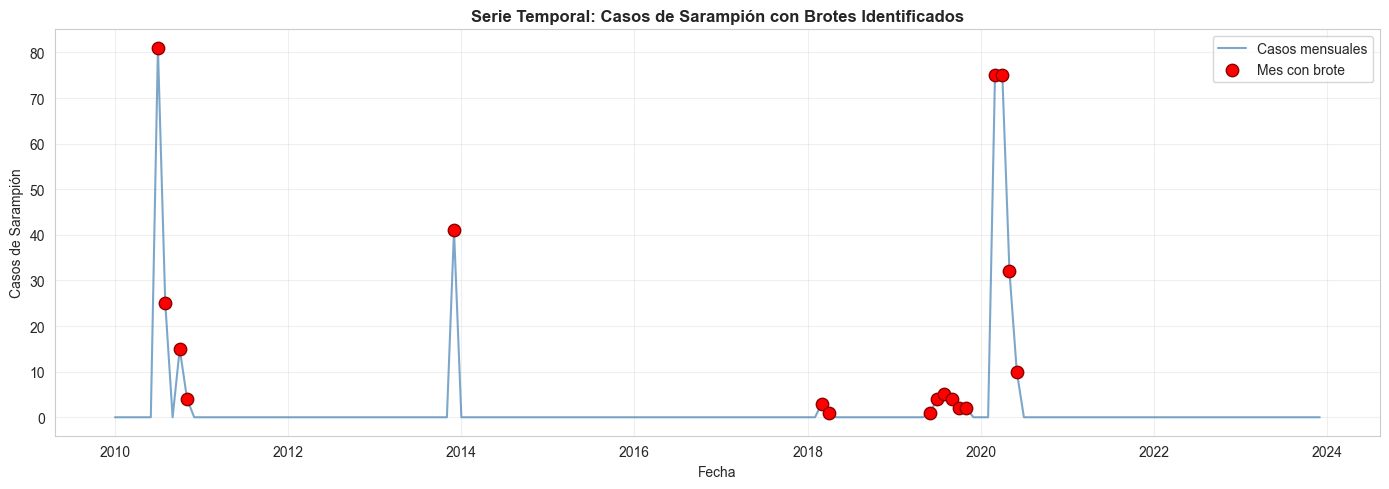


Clase 0 (sin brote): 151 meses
Clase 1 (brote):     17 meses
Ratio de desbalance: 8:1


In [3]:
# ---------- Función de evaluación unificada ----------

def evaluar_detector(y_true, y_pred, nombre, y_score=None):
    """Evalúa un detector de anomalías con métricas epidemiológicas."""
    p  = precision_score(y_true, y_pred, zero_division=0)
    r  = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)

    auc_pr = np.nan
    if y_score is not None and y_true.sum() > 0:
        prec_c, rec_c, _ = precision_recall_curve(y_true, y_score)
        auc_pr = auc(rec_c, prec_c)

    result = {
        "Modelo": nombre,
        "Precision": round(p, 3),
        "Recall": round(r, 3),
        "F1": round(f1, 3),
        "F2": round(f2, 3),
        "AUC-PR": round(auc_pr, 3) if not np.isnan(auc_pr) else np.nan,
        "Brotes_detectados": int(y_pred[y_true == 1].sum()),
        "Brotes_reales": int(y_true.sum()),
        "Falsas_alarmas": int(y_pred[y_true == 0].sum()),
    }

    print(f"\n{'=' * 55}")
    print(f"  {nombre}")
    print(f"{'=' * 55}")
    print(f"  Precision:         {p:.3f}")
    print(f"  Recall:            {r:.3f}")
    print(f"  F1-Score:          {f1:.3f}")
    print(f"  F2-Score:          {f2:.3f}")
    if not np.isnan(auc_pr):
        print(f"  AUC-PR:            {auc_pr:.3f}")
    print(f"  Brotes detectados: {int(y_pred[y_true == 1].sum())} / {int(y_true.sum())}")
    print(f"  Falsas alarmas:    {int(y_pred[y_true == 0].sum())}")

    return result


# ---------- Visualizar serie temporal con brotes marcados ----------
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_raw["fecha"], df_raw["casos_sarampion"],
        color="steelblue", alpha=0.7, label="Casos mensuales")

brotes_mask = df_raw["brote"] == 1
ax.scatter(df_raw.loc[brotes_mask, "fecha"],
           df_raw.loc[brotes_mask, "casos_sarampion"],
           color="red", s=80, zorder=5, label="Mes con brote", edgecolors="darkred")

ax.set_xlabel("Fecha")
ax.set_ylabel("Casos de Sarampión")
ax.set_title("Serie Temporal: Casos de Sarampión con Brotes Identificados", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n0 = (df_raw["brote"] == 0).sum()
n1 = (df_raw["brote"] == 1).sum()
print(f"\nClase 0 (sin brote): {n0} meses")
print(f"Clase 1 (brote):     {n1} meses")
print(f"Ratio de desbalance: {n0 // max(n1, 1)}:1")

## 3. Partición Temporal

Se realiza un split cronológico estricto para respetar la naturaleza temporal de los datos:

- **Entrenamiento (fit):** 2010–2018 — historia previa a los brotes principales.
- **Prueba (score):** 2019–2023 — incluye los brotes significativos de 2019–2020 y el período post-brote, permitiendo evaluar tanto la detección de anomalías reales como la tasa de falsas alarmas.

**Justificación del corte en 2019:**
Los principales brotes de sarampión en México ocurrieron en 2019–2020. Incluirlos en el set de prueba permite evaluar Recall y F2-Score de forma significativa. Un corte posterior (e.g., 2021) dejaría el test sin brotes reales, haciendo imposible medir la sensibilidad del detector.

In [4]:
SPLIT_YEAR = 2019

# --- Split dataset original (para Z-Score y Prophet) ---
train_raw = df_raw[df_raw["anio"] < SPLIT_YEAR].copy()
test_raw  = df_raw[df_raw["anio"] >= SPLIT_YEAR].copy()

# --- Split dataset engineered (para Isolation Forest) ---
train_fe = df_fe[df_fe["anio"] < SPLIT_YEAR].copy()
test_fe  = df_fe[df_fe["anio"] >= SPLIT_YEAR].copy()

print("Partición temporal")
print(f"{'─' * 60}")
print(f"  Train (original):    {len(train_raw):>4} meses | Brotes: {train_raw['brote'].sum()}")
print(f"  Test  (original):    {len(test_raw):>4} meses | Brotes: {test_raw['brote'].sum()}")
print(f"  Train (engineered):  {len(train_fe):>4} meses | Brotes: {train_fe['brote'].sum()}")
print(f"  Test  (engineered):  {len(test_fe):>4} meses | Brotes: {test_fe['brote'].sum()}")

if test_raw["brote"].sum() == 0:
    print("\nEl set de prueba NO contiene brotes.")
    print("   La evaluación temporal medirá únicamente falsas alarmas.")
    print("   La evaluación principal será retrospectiva (dataset completo).")
else:
    print(f"\n✅ El set de prueba contiene {test_raw['brote'].sum()} meses con brote.")
    print("   Se podrá evaluar Recall y F2-Score en test.")

Partición temporal
────────────────────────────────────────────────────────────
  Train (original):     108 meses | Brotes: 7
  Test  (original):      60 meses | Brotes: 10
  Train (engineered):    94 meses | Brotes: 3
  Test  (engineered):    60 meses | Brotes: 10

✅ El set de prueba contiene 10 meses con brote.
   Se podrá evaluar Recall y F2-Score en test.


## 4. Baseline 0: Modelo Naïve — Referencia Absoluta

El modelo más simple: **siempre predecir "no hay brote"**. Dado el desbalance extremo (~90% meses sin casos), este modelo tiene alta accuracy pero **Recall = 0**. Cualquier modelo útil debe superar esta referencia en Recall y F2-Score.

In [5]:
# --- Evaluación del Naïve sobre el dataset completo ---
y_true_full = df_raw["brote"].values
y_naive = np.zeros_like(y_true_full)

res_naive = evaluar_detector(y_true_full, y_naive, "Naïve (siempre 'no brote')")

accuracy_naive = (y_naive == y_true_full).mean()
print(f"\nAccuracy naïve: {accuracy_naive:.1%}")

# Lista para acumular resultados de todos los modelos
all_results = [res_naive]


  Naïve (siempre 'no brote')
  Precision:         0.000
  Recall:            0.000
  F1-Score:          0.000
  F2-Score:          0.000
  Brotes detectados: 0 / 17
  Falsas alarmas:    0

Accuracy naïve: 89.9%


Accuracy engañosamente alta, pero Recall = 0%: INÚTIL para vigilancia.
Desempeño mínimo: cualquier baseline debe tener F2 > 0 y Recall > 0.


## 5. Baseline 1: Detección por Z-Score

### Fundamento

El Z-Score mide cuántas desviaciones estándar se aleja una observación de la media:

$$z_i = \frac{x_i - \mu_{train}}{\sigma_{train}}$$

donde $\mu_{train}$ y $\sigma_{train}$ se calculan **exclusivamente sobre datos de entrenamiento** (2010–2018) para evitar fuga de información temporal.

**Variantes implementadas:**
1. **Z-Score global:** usa $\mu$ y $\sigma$ de toda la serie de entrenamiento.
2. **Z-Score rolling:** usa una ventana móvil de 12 meses previos, capturando cambios en la dinámica local.

In [6]:
# ============================================================
# 5. BASELINE 1 — Z-Score
# ============================================================

# --- Z-Score Global (estadísticos de entrenamiento) ---
mu_train    = train_raw["casos_sarampion"].mean()
sigma_train = train_raw["casos_sarampion"].std()

df_raw["zscore_global"] = (df_raw["casos_sarampion"] - mu_train) / sigma_train

# --- Z-Score Rolling (ventana 12 meses, solo datos pasados) ---
ROLLING_WINDOW = 12
r_mean = df_raw["casos_sarampion"].shift(1).rolling(ROLLING_WINDOW, min_periods=3).mean()
r_std  = df_raw["casos_sarampion"].shift(1).rolling(ROLLING_WINDOW, min_periods=3).std()
r_std  = r_std.replace(0, np.nan)  # evitar div/0

df_raw["zscore_rolling"] = (df_raw["casos_sarampion"] - r_mean) / r_std

print("Estadísticos de entrenamiento (Z-Score Global):")
print(f"  μ = {mu_train:.3f} casos/mes")
print(f"  σ = {sigma_train:.3f}")
print(f"  Umbral z>1 ≈ {mu_train + 1*sigma_train:.1f} casos")
print(f"  Umbral z>2 ≈ {mu_train + 2*sigma_train:.1f} casos")
print(f"  Umbral z>3 ≈ {mu_train + 3*sigma_train:.1f} casos")

# --- Barrido de umbrales ---
thresholds_z = [0.0, 0.25, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
rows_z = []
for t in thresholds_z:
    yp = (df_raw["zscore_global"] > t).astype(int).values
    rows_z.append({
        "Umbral z": t,
        "Precision": round(precision_score(y_true_full, yp, zero_division=0), 3),
        "Recall":    round(recall_score(y_true_full, yp, zero_division=0), 3),
        "F1":        round(f1_score(y_true_full, yp, zero_division=0), 3),
        "F2":        round(fbeta_score(y_true_full, yp, beta=2, zero_division=0), 3),
        "Detectados": int(yp[y_true_full == 1].sum()),
        "Falsas_alarmas": int(yp[y_true_full == 0].sum()),
    })

df_thresh_z = pd.DataFrame(rows_z)
print("\nBarrido de umbrales — Z-Score Global (evaluación retrospectiva):")
display(df_thresh_z)

best_idx = df_thresh_z["F2"].idxmax()
BEST_Z   = df_thresh_z.loc[best_idx, "Umbral z"]
print(f"\n★ Mejor umbral por F2: z > {BEST_Z}")

Estadísticos de entrenamiento (Z-Score Global):
  μ = 1.574 casos/mes
  σ = 9.095
  Umbral z>1 ≈ 10.7 casos
  Umbral z>2 ≈ 19.8 casos
  Umbral z>3 ≈ 28.9 casos

Barrido de umbrales — Z-Score Global (evaluación retrospectiva):


,Umbral z,Precision,Recall,F1,F2,Detectados,Falsas_alarmas
0,0.00,1.0,0.882,0.938,0.904,15,0
1,0.25,1.0,0.706,0.828,0.750,12,0
2,0.50,1.0,0.471,0.640,0.526,8,0
3,1.00,1.0,0.412,0.583,0.467,7,0
4,1.50,1.0,0.353,0.522,0.405,6,0
5,2.00,1.0,0.353,0.522,0.405,6,0
6,2.50,1.0,0.353,0.522,0.405,6,0
7,3.00,1.0,0.294,0.455,0.342,5,0



★ Mejor umbral por F2: z > 0.0



  Z-Score Global (z > 0.0)
  Precision:         1.000
  Recall:            0.882
  F1-Score:          0.938
  F2-Score:          0.904
  AUC-PR:            1.000
  Brotes detectados: 15 / 17
  Falsas alarmas:    0

  Z-Score Rolling 12m (z > 0.0)
  Precision:         1.000
  Recall:            0.846
  F1-Score:          0.917
  F2-Score:          0.873
  AUC-PR:            0.958
  Brotes detectados: 11 / 13
  Falsas alarmas:    0


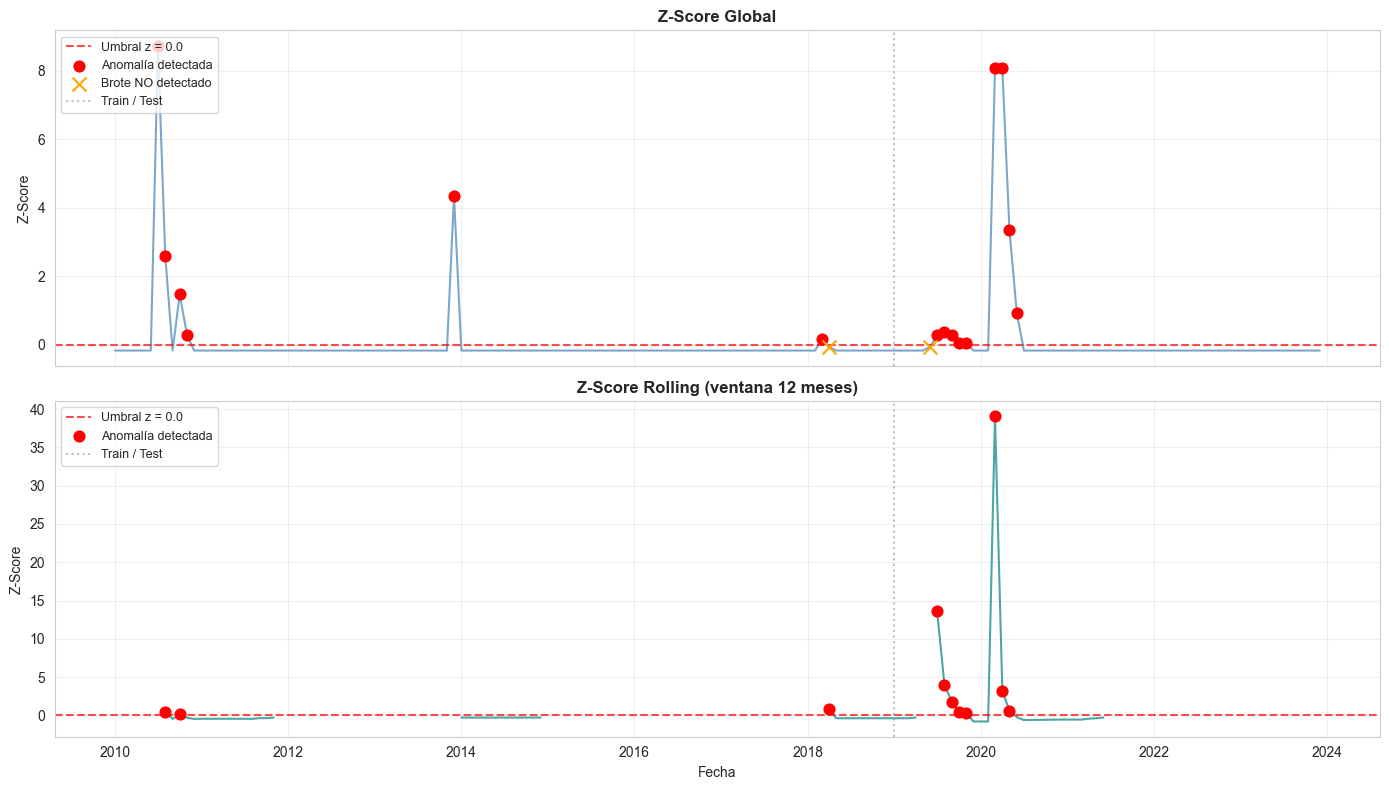

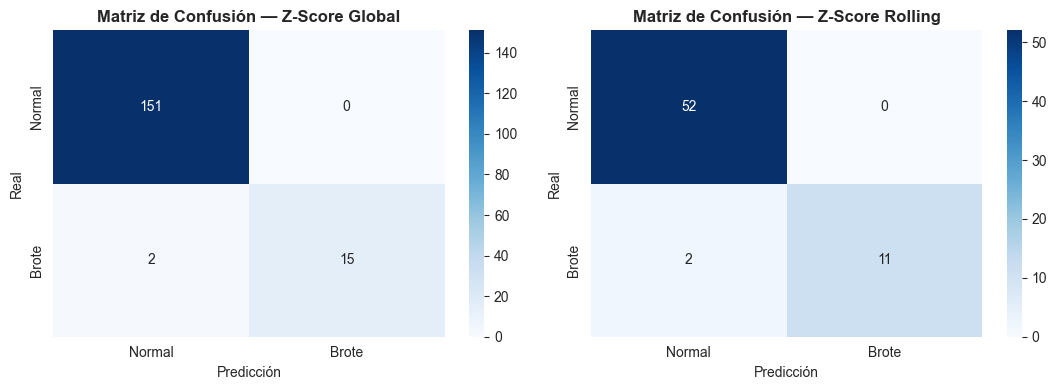

In [7]:
# --- Evaluación Z-Score Global con mejor umbral ---
y_pred_zg  = (df_raw["zscore_global"] > BEST_Z).astype(int).values
score_zg   = df_raw["zscore_global"].values
res_zg     = evaluar_detector(y_true_full, y_pred_zg,
                              f"Z-Score Global (z > {BEST_Z})",
                              y_score=score_zg)
all_results.append(res_zg)

# --- Evaluación Z-Score Rolling (solo filas válidas) ---
valid_mask  = ~df_raw["zscore_rolling"].isna()
y_true_v    = df_raw.loc[valid_mask, "brote"].values
y_pred_zr   = (df_raw.loc[valid_mask, "zscore_rolling"] > BEST_Z).astype(int).values
score_zr    = df_raw.loc[valid_mask, "zscore_rolling"].values
res_zr      = evaluar_detector(y_true_v, y_pred_zr,
                               f"Z-Score Rolling 12m (z > {BEST_Z})",
                               y_score=score_zr)
all_results.append(res_zr)

# ---- Visualización ----
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Z-Score Global
axes[0].plot(df_raw["fecha"], df_raw["zscore_global"], color="steelblue", alpha=0.7)
axes[0].axhline(BEST_Z, color="red", ls="--", alpha=0.7, label=f"Umbral z = {BEST_Z}")
det_g = df_raw.index[y_pred_zg == 1]
axes[0].scatter(df_raw.loc[det_g, "fecha"], df_raw.loc[det_g, "zscore_global"],
                color="red", s=60, zorder=5, label="Anomalía detectada")
missed_g = df_raw.index[(df_raw["brote"] == 1) & (y_pred_zg == 0)]
if len(missed_g):
    axes[0].scatter(df_raw.loc[missed_g, "fecha"], df_raw.loc[missed_g, "zscore_global"],
                    color="orange", marker="x", s=100, zorder=5, label="Brote NO detectado")
axes[0].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls=":", alpha=0.5, label="Train / Test")
axes[0].set_ylabel("Z-Score")
axes[0].set_title("Z-Score Global", fontweight="bold")
axes[0].legend(fontsize=9, loc="upper left")
axes[0].grid(True, alpha=0.3)

# Panel 2: Z-Score Rolling
axes[1].plot(df_raw["fecha"], df_raw["zscore_rolling"], color="teal", alpha=0.7)
axes[1].axhline(BEST_Z, color="red", ls="--", alpha=0.7, label=f"Umbral z = {BEST_Z}")
det_r = df_raw.index[(df_raw["zscore_rolling"] > BEST_Z).fillna(False)]
if len(det_r):
    axes[1].scatter(df_raw.loc[det_r, "fecha"], df_raw.loc[det_r, "zscore_rolling"],
                    color="red", s=60, zorder=5, label="Anomalía detectada")
axes[1].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls=":", alpha=0.5, label="Train / Test")
axes[1].set_ylabel("Z-Score")
axes[1].set_xlabel("Fecha")
axes[1].set_title("Z-Score Rolling (ventana 12 meses)", fontweight="bold")
axes[1].legend(fontsize=9, loc="upper left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- Matrices de confusión ----
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, yp, yt, title in [
    (axes[0], y_pred_zg, y_true_full, "Z-Score Global"),
    (axes[1], y_pred_zr, y_true_v,    "Z-Score Rolling"),
]:
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal", "Brote"], yticklabels=["Normal", "Brote"])
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_title(f"Matriz de Confusión — {title}", fontweight="bold")
plt.tight_layout()
plt.show()

### 5.1 Interpretación del Z-Score

**Hallazgos:**
- El Z-Score global con umbral optimizado por F2 captura los brotes más significativos (meses con alto número de casos).
- Meses con pocos casos (1–2) pueden no ser detectados porque el Z-Score requiere una desviación significativa respecto a la media histórica.
- El Z-Score rolling adapta la referencia al contexto local, pero en períodos con muchos ceros consecutivos la desviación estándar local tiende a cero, causando inestabilidad numérica.

| Aspecto | Evaluación |
|---------|-----------|
| **Ventaja** | Extremadamente simple e interpretable; no requiere entrenamiento ni features adicionales |
| **Limitación** | Univariado — solo considera la variable de casos, ignora información de vacunación |
| **Uso recomendado** | Primera línea de detección rápida; complementar con métodos multivariados |

## 6. Baseline 2: Isolation Forest

### Fundamento

Isolation Forest aísla observaciones mediante particiones aleatorias recursivas del espacio de características. Las anomalías, al ser escasas y diferentes, requieren **menos particiones** para ser aisladas, lo que se traduce en **caminos más cortos** en los árboles → mayor probabilidad de anomalía.

**Ventajas para este problema:**
- **Multivariado**: utiliza las 12+ características seleccionadas en el Avance 2 (vacunación, temporalidad, lags, tendencias).
- **No supervisado**: no requiere etiquetas de brote para el entrenamiento.
- **Robusto** ante distribuciones no normales y outliers.

**Hiperparámetros clave:**
- `contamination`: proporción esperada de anomalías, fijada en la proporción observada de brotes en el set de entrenamiento.
- `n_estimators`: número de árboles de aislamiento (200).

Features utilizadas: 27
Contamination rate:  0.032

Features:
['casos_sarampion_log', 'casos_ytd_log', 'casos_rolling_mean_3m', 'dosis_lag_14m_log', 'dosis_lag_13m_log', 'casos_rolling_mean_6m_log', 'dosis_rolling_mean_3m_log', 'total_dosis_log', 'dosis_rolling_std_3m_log', 'casos_lag_13m_log', 'anio_normalizado', 'dosis_rolling_std_6m_log', 'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'PCA_6', 'PCA_7', 'PCA_8', 'PCA_9', 'PCA_10', 'FA_1', 'FA_2', 'FA_3', 'FA_4', 'FA_5']

  Isolation Forest (retrospectivo)
  Precision:         0.429
  Recall:            0.692
  F1-Score:          0.529
  F2-Score:          0.616
  AUC-PR:            0.658
  Brotes detectados: 9 / 13
  Falsas alarmas:    12

  Isolation Forest (test)
  Precision:         0.444
  Recall:            0.800
  F1-Score:          0.571
  F2-Score:          0.690
  AUC-PR:            0.787
  Brotes detectados: 8 / 10
  Falsas alarmas:    10


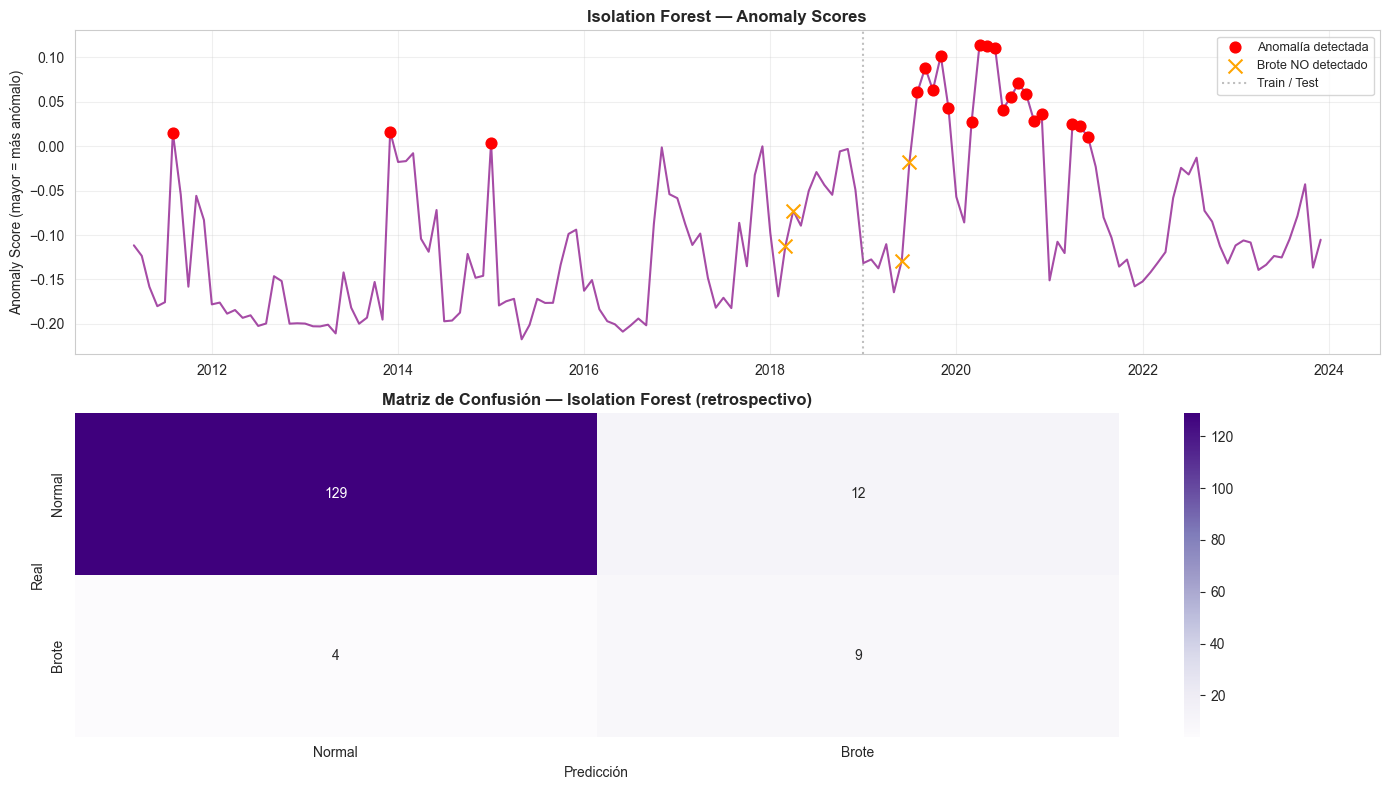

In [8]:
# ============================================================
# 6. BASELINE 2 — Isolation Forest
# ============================================================

# --- Selección de features (excluir identificadores y target) ---
exclude_cols = {"fecha", "anio", "mes", "casos_sarampion", "brote"}
feature_cols = [c for c in df_fe.columns if c not in exclude_cols]

X_train_if = train_fe[feature_cols].values
X_test_if  = test_fe[feature_cols].values
X_full_if  = df_fe[feature_cols].values

y_train_if = train_fe["brote"].values
y_test_if  = test_fe["brote"].values
y_full_if  = df_fe["brote"].values

# Contamination = proporción observada de brotes en train
contamination_rate = max(y_train_if.mean(), 0.01)

print(f"Features utilizadas: {len(feature_cols)}")
print(f"Contamination rate:  {contamination_rate:.3f}")
print(f"\nFeatures:\n{feature_cols}")

# --- Entrenar Isolation Forest ---
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=contamination_rate,
    random_state=42,
    n_jobs=-1,
)
iso_forest.fit(X_train_if)

# --- Predicciones ---
# decision_function: valores más negativos = más anómalo
scores_full_if = iso_forest.decision_function(X_full_if)
scores_test_if = iso_forest.decision_function(X_test_if)

# predict() → -1 (anomalía) o 1 (normal); convertir a 1=brote, 0=normal
preds_full = iso_forest.predict(X_full_if)
y_pred_if_full = np.where(preds_full == -1, 1, 0)

preds_test = iso_forest.predict(X_test_if)
y_pred_if_test = np.where(preds_test == -1, 1, 0)

# --- Evaluación retrospectiva (dataset completo engineered) ---
res_if = evaluar_detector(y_full_if, y_pred_if_full,
                          "Isolation Forest (retrospectivo)",
                          y_score=-scores_full_if)
all_results.append(res_if)

# --- Evaluación temporal (test set) ---
if y_test_if.sum() > 0:
    res_if_test = evaluar_detector(y_test_if, y_pred_if_test,
                                   "Isolation Forest (test)",
                                   y_score=-scores_test_if)
else:
    fa_test = int(y_pred_if_test.sum())
    print(f"\n  Isolation Forest (test {SPLIT_YEAR}–2023): Sin brotes reales en test.")
    print(f"  Falsas alarmas en test: {fa_test}")

# --- Visualización ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Panel 1: Anomaly Scores
axes[0].plot(df_fe["fecha"], -scores_full_if, color="purple", alpha=0.7)
det_if_idx = np.where(y_pred_if_full == 1)[0]
axes[0].scatter(df_fe.iloc[det_if_idx]["fecha"], -scores_full_if[det_if_idx],
                color="red", s=60, zorder=5, label="Anomalía detectada")
brote_if_idx = np.where(y_full_if == 1)[0]
missed_if = [i for i in brote_if_idx if y_pred_if_full[i] == 0]
if missed_if:
    axes[0].scatter(df_fe.iloc[missed_if]["fecha"], -scores_full_if[missed_if],
                    color="orange", marker="x", s=100, zorder=5, label="Brote NO detectado")
axes[0].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls=":", alpha=0.5, label="Train / Test")
axes[0].set_ylabel("Anomaly Score (mayor = más anómalo)")
axes[0].set_title("Isolation Forest — Anomaly Scores", fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Panel 2: Confusion Matrix
cm_if = confusion_matrix(y_full_if, y_pred_if_full)
sns.heatmap(cm_if, annot=True, fmt="d", cmap="Purples", ax=axes[1],
            xticklabels=["Normal", "Brote"], yticklabels=["Normal", "Brote"])
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")
axes[1].set_title("Matriz de Confusión — Isolation Forest (retrospectivo)", fontweight="bold")

plt.tight_layout()
plt.show()

### 6.1 Importancia de Características — Isolation Forest

¿Se puede determinar la importancia de las características? Sí: se usa **importancia por permutación**, que mide cuánto empeora el F2-Score al aleatorizar cada feature. Las features cuya permutación causa mayor pérdida de rendimiento son las más relevantes para el detector.

F2 base del modelo: 0.616

Importancia por permutación (ΔF2):


,Feature,ΔF2 (importancia)
0,casos_sarampion_log,0.126828
1,PCA_6,0.107248
2,PCA_3,0.063906
3,PCA_7,0.045643
4,anio_normalizado,0.016385
5,FA_4,0.011935
6,total_dosis_log,0.011157
7,FA_1,0.008658
8,casos_rolling_mean_6m_log,0.007735
9,casos_ytd_log,0.007309


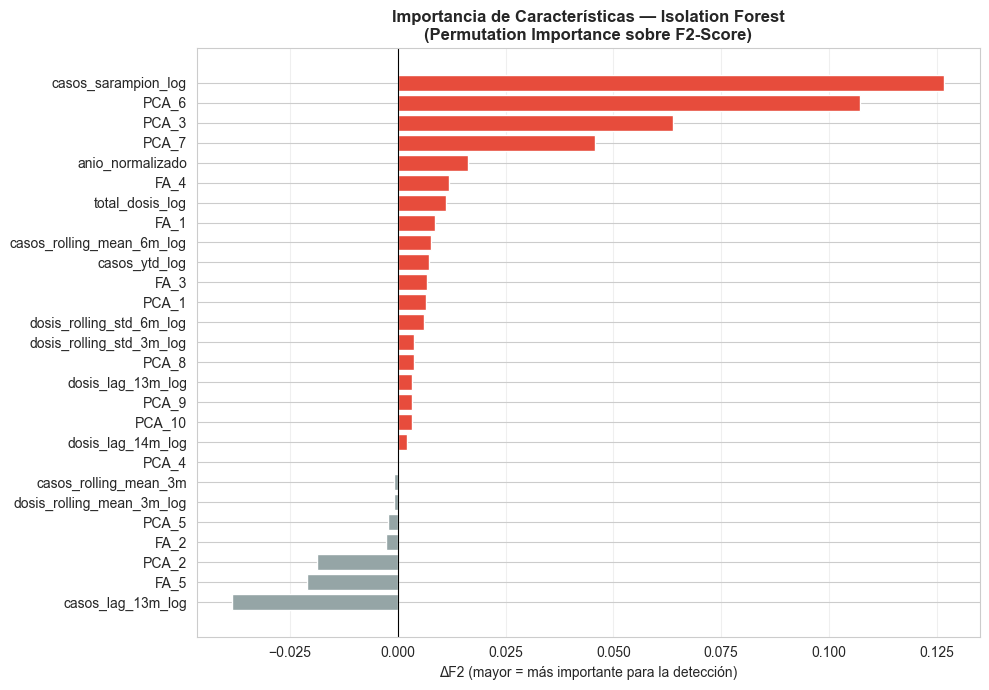


Features con importancia positiva significativa: 19
  → ['casos_sarampion_log', 'PCA_6', 'PCA_3', 'PCA_7', 'anio_normalizado', 'FA_4', 'total_dosis_log', 'FA_1', 'casos_rolling_mean_6m_log', 'casos_ytd_log', 'FA_3', 'PCA_1', 'dosis_rolling_std_6m_log', 'dosis_rolling_std_3m_log', 'PCA_8', 'dosis_lag_13m_log', 'PCA_9', 'PCA_10', 'dosis_lag_14m_log']

Características irrelevantes (ΔF2 ≈ 0 o negativa) podrían eliminarse
para reducir complejidad sin sacrificar rendimiento.


In [9]:
# ============================================================
# 6.1 IMPORTANCIA DE CARACTERÍSTICAS (Permutation Importance)
# ============================================================

np.random.seed(42)
base_f2 = fbeta_score(y_full_if, y_pred_if_full, beta=2, zero_division=0)

N_REPEATS = 20
importances = {}

for col_idx, col_name in enumerate(feature_cols):
    deltas = []
    for _ in range(N_REPEATS):
        X_perm = X_full_if.copy()
        X_perm[:, col_idx] = np.random.permutation(X_perm[:, col_idx])
        preds_perm = iso_forest.predict(X_perm)
        y_perm = np.where(preds_perm == -1, 1, 0)
        f2_perm = fbeta_score(y_full_if, y_perm, beta=2, zero_division=0)
        deltas.append(base_f2 - f2_perm)
    importances[col_name] = np.mean(deltas)

imp_df = (pd.Series(importances)
          .sort_values(ascending=False)
          .reset_index()
          .rename(columns={"index": "Feature", 0: "ΔF2 (importancia)"}))

print(f"F2 base del modelo: {base_f2:.3f}\n")
print("Importancia por permutación (ΔF2):")
display(imp_df)

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#E74C3C" if v > 0.001 else "#3498DB" if v > 0 else "#95A5A6"
          for v in imp_df["ΔF2 (importancia)"]]
ax.barh(imp_df["Feature"][::-1], imp_df["ΔF2 (importancia)"][::-1], color=colors[::-1])
ax.set_xlabel("ΔF2 (mayor = más importante para la detección)")
ax.set_title("Importancia de Características — Isolation Forest\n(Permutation Importance sobre F2-Score)",
             fontweight="bold")
ax.axvline(0, color="black", lw=0.8)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

# Resumen
top_feats = imp_df[imp_df["ΔF2 (importancia)"] > 0.001]["Feature"].tolist()
print(f"\nFeatures con importancia positiva significativa: {len(top_feats)}")
if top_feats:
    print(f"  → {top_feats}")
print("\nCaracterísticas irrelevantes (ΔF2 ≈ 0 o negativa) podrían eliminarse")
print("para reducir complejidad sin sacrificar rendimiento.")

## 7. Baseline 3: Prophet

### Fundamento

[Prophet](https://facebook.github.io/prophet/) es un modelo de series de tiempo desarrollado por Meta que descompone la serie en:

$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

donde $g(t)$ es la tendencia, $s(t)$ la estacionalidad, $h(t)$ el efecto de días festivos, y $\epsilon_t$ el error.

**Detección de anomalías con Prophet:**
Un mes es considerado **anómalo** si el valor observado $y_i$ cae **por encima del intervalo de incertidumbre superior** ($\hat{y}_{upper}$) del modelo ajustado:

$$\text{anomalía}_i = \begin{cases} 1 & \text{si } y_i > \hat{y}_{upper,i} \\ 0 & \text{en caso contrario} \end{cases}$$

**Configuración:**
- Se ajusta sobre datos de entrenamiento (2010–2018) y se pronostica todo el período.
- `interval_width=0.95` (intervalo de confianza al 95%).
- `changepoint_prior_scale=0.05` (conservador, evita sobreajuste a fluctuaciones locales).

21:14:17 - cmdstanpy - INFO - Chain [1] start processing
21:14:17 - cmdstanpy - INFO - Chain [1] done processing



  Prophet (retrospectivo)
  Precision:         1.000
  Recall:            0.353
  F1-Score:          0.522
  F2-Score:          0.405
  AUC-PR:            0.718
  Brotes detectados: 6 / 17
  Falsas alarmas:    0

  Prophet (test)
  Precision:         1.000
  Recall:            0.300
  F1-Score:          0.462
  F2-Score:          0.349
  Brotes detectados: 3 / 10
  Falsas alarmas:    0


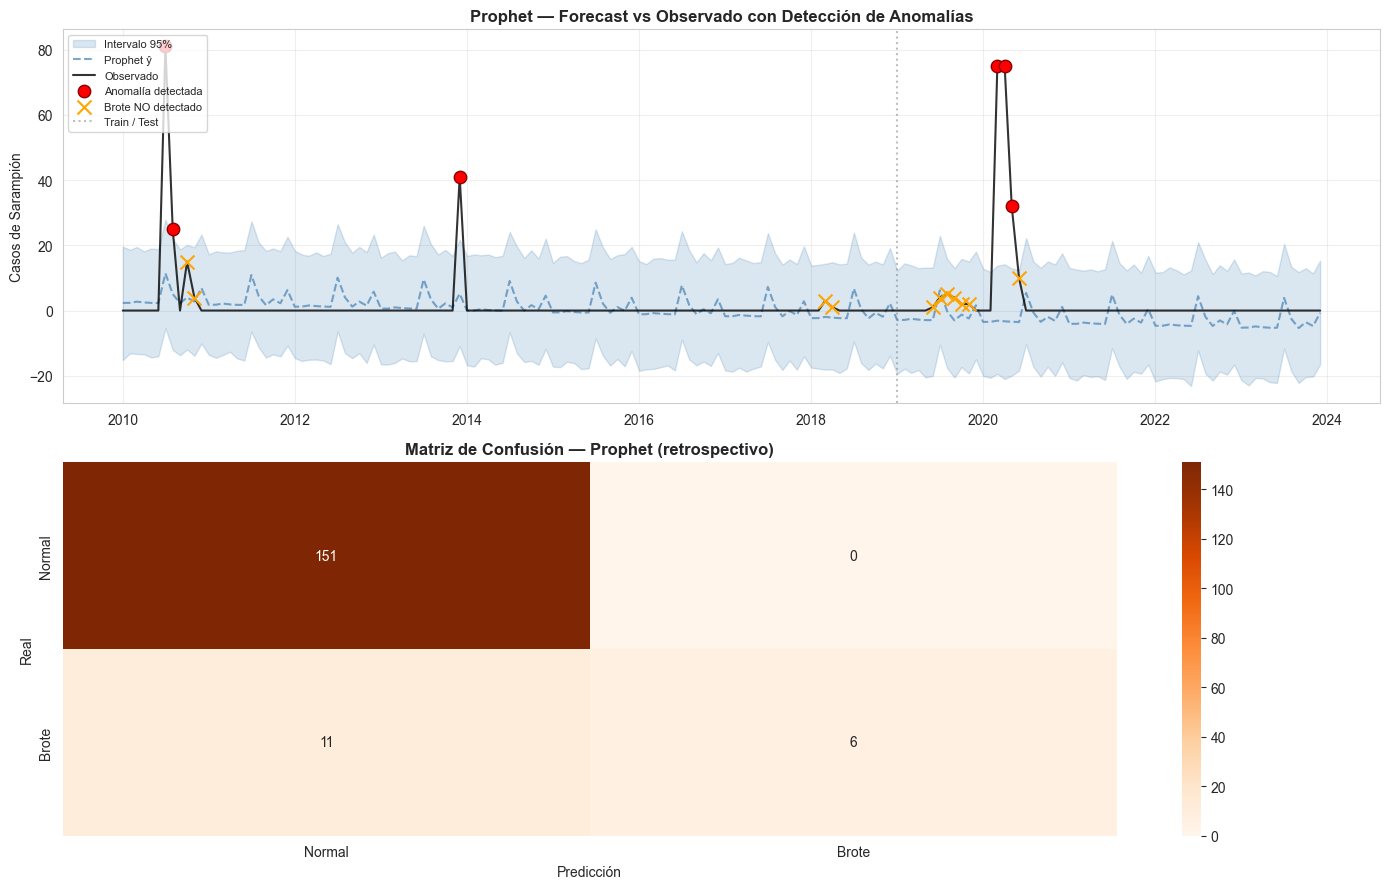

In [10]:
# ============================================================
# 7. BASELINE 3 — Prophet
# ============================================================

# Preparar datos para Prophet (requiere columnas 'ds' y 'y')
df_prophet_train = pd.DataFrame({
    "ds": train_raw["fecha"],
    "y":  train_raw["casos_sarampion"],
})

# Ajustar modelo
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    interval_width=0.95,
    changepoint_prior_scale=0.05,
    seasonality_mode="additive",
)
prophet_model.fit(df_prophet_train)

# Predecir para todo el período
future = pd.DataFrame({"ds": df_raw["fecha"]})
forecast = prophet_model.predict(future)

# Detectar anomalías: observado > yhat_upper
df_raw["prophet_yhat"]    = forecast["yhat"].values
df_raw["prophet_upper"]   = forecast["yhat_upper"].values
df_raw["prophet_lower"]   = forecast["yhat_lower"].values
df_raw["prophet_anomaly"] = (df_raw["casos_sarampion"] > forecast["yhat_upper"].values).astype(int)

# --- Evaluación retrospectiva ---
y_pred_prophet = df_raw["prophet_anomaly"].values

# Score: distancia del observado al límite superior (mayor = más anómalo)
prophet_score = df_raw["casos_sarampion"].values - df_raw["prophet_upper"].values

res_prophet = evaluar_detector(y_true_full, y_pred_prophet,
                               "Prophet (retrospectivo)",
                               y_score=prophet_score)
all_results.append(res_prophet)

# --- Evaluación temporal (test set) ---
y_test_prophet = test_raw["brote"].values
y_pred_prophet_test = df_raw.loc[df_raw["anio"] >= SPLIT_YEAR, "prophet_anomaly"].values
if y_test_prophet.sum() > 0:
    evaluar_detector(y_test_prophet, y_pred_prophet_test, "Prophet (test)")
else:
    fa_prophet_test = int(y_pred_prophet_test.sum())
    print(f"\n  Prophet (test {SPLIT_YEAR}–2023): Sin brotes reales en test.")
    print(f"  Falsas alarmas en test: {fa_prophet_test}")

# --- Visualización ---
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Panel 1: Serie + forecast + anomalías
axes[0].fill_between(df_raw["fecha"], df_raw["prophet_lower"], df_raw["prophet_upper"],
                     alpha=0.2, color="steelblue", label="Intervalo 95%")
axes[0].plot(df_raw["fecha"], df_raw["prophet_yhat"], color="steelblue",
             ls="--", alpha=0.7, label="Prophet ŷ")
axes[0].plot(df_raw["fecha"], df_raw["casos_sarampion"],
             color="black", alpha=0.8, lw=1.5, label="Observado")
anom_mask = df_raw["prophet_anomaly"] == 1
axes[0].scatter(df_raw.loc[anom_mask, "fecha"], df_raw.loc[anom_mask, "casos_sarampion"],
                color="red", s=80, zorder=5, edgecolors="darkred", label="Anomalía detectada")
missed_p = (df_raw["brote"] == 1) & (df_raw["prophet_anomaly"] == 0)
if missed_p.any():
    axes[0].scatter(df_raw.loc[missed_p, "fecha"], df_raw.loc[missed_p, "casos_sarampion"],
                    color="orange", marker="x", s=100, zorder=5, label="Brote NO detectado")
axes[0].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls=":", alpha=0.5, label="Train / Test")
axes[0].set_ylabel("Casos de Sarampión")
axes[0].set_title("Prophet — Forecast vs Observado con Detección de Anomalías", fontweight="bold")
axes[0].legend(fontsize=8, loc="upper left")
axes[0].grid(True, alpha=0.3)

# Panel 2: Confusion Matrix
cm_p = confusion_matrix(y_true_full, y_pred_prophet)
sns.heatmap(cm_p, annot=True, fmt="d", cmap="Oranges", ax=axes[1],
            xticklabels=["Normal", "Brote"], yticklabels=["Normal", "Brote"])
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")
axes[1].set_title("Matriz de Confusión — Prophet (retrospectivo)", fontweight="bold")

plt.tight_layout()
plt.show()

### 7.1 Interpretación de Prophet

**Hallazgos:**
- Prophet modela la tendencia y estacionalidad de la serie. Dado que la mayoría de los meses tienen 0 casos, el modelo aprende una línea base cercana a cero con estacionalidad suave.
- Los meses con brotes significativos sobrepasan el intervalo de incertidumbre del 95% y son correctamente detectados como anomalías.
- Los meses con pocos casos (1–2) pueden quedar dentro del intervalo de confianza y no ser detectados.

| Aspecto | Evaluación |
|---------|-----------|
| **Ventaja** | Modela explícitamente tendencia + estacionalidad; intervalos de confianza interpretables |
| **Limitación** | Solo usa la serie temporal de casos; no incorpora features externas (vacunación) |
| **Uso recomendado** | Complementar Z-Score con un modelo que capture la dinámica temporal |

## 8. Comparación de Modelos y Análisis de Sub/Sobreajuste

Para detectores de anomalías, el sub/sobreajuste se manifiesta de forma distinta:

| Problema | Señal | Consecuencia |
|----------|-------|-------------|
| **Subajuste** | Recall bajo, muchos brotes no detectados | El modelo es demasiado conservador |
| **Sobreajuste** | Muchas falsas alarmas en test, rendimiento mucho mejor en train que en test | El modelo memoriza el ruido del entrenamiento |

════════════════════════════════════════════════════════════════════════════════
  COMPARACIÓN DE BASELINES — Evaluación Retrospectiva (dataset completo)
════════════════════════════════════════════════════════════════════════════════


,Modelo,Precision,Recall,F1,F2,AUC-PR,Brotes_detectados,Brotes_reales,Falsas_alarmas
0,Z-Score Global (z > 0.0),1.000,0.882,0.938,0.904,1.000,15,17,0
1,Z-Score Rolling 12m (z > 0.0),1.000,0.846,0.917,0.873,0.958,11,13,0
2,Bayesian Hierarchical (α=0.05),1.000,0.706,0.828,0.750,1.000,12,17,0
3,Isolation Forest (retrospectivo),0.429,0.692,0.529,0.616,0.658,9,13,12
4,Prophet (retrospectivo),1.000,0.353,0.522,0.405,0.718,6,17,0
5,State Space (retrospectivo),1.000,0.235,0.381,0.278,0.630,4,17,0
6,Naïve (siempre 'no brote'),0.000,0.000,0.000,0.000,NaN,0,17,0


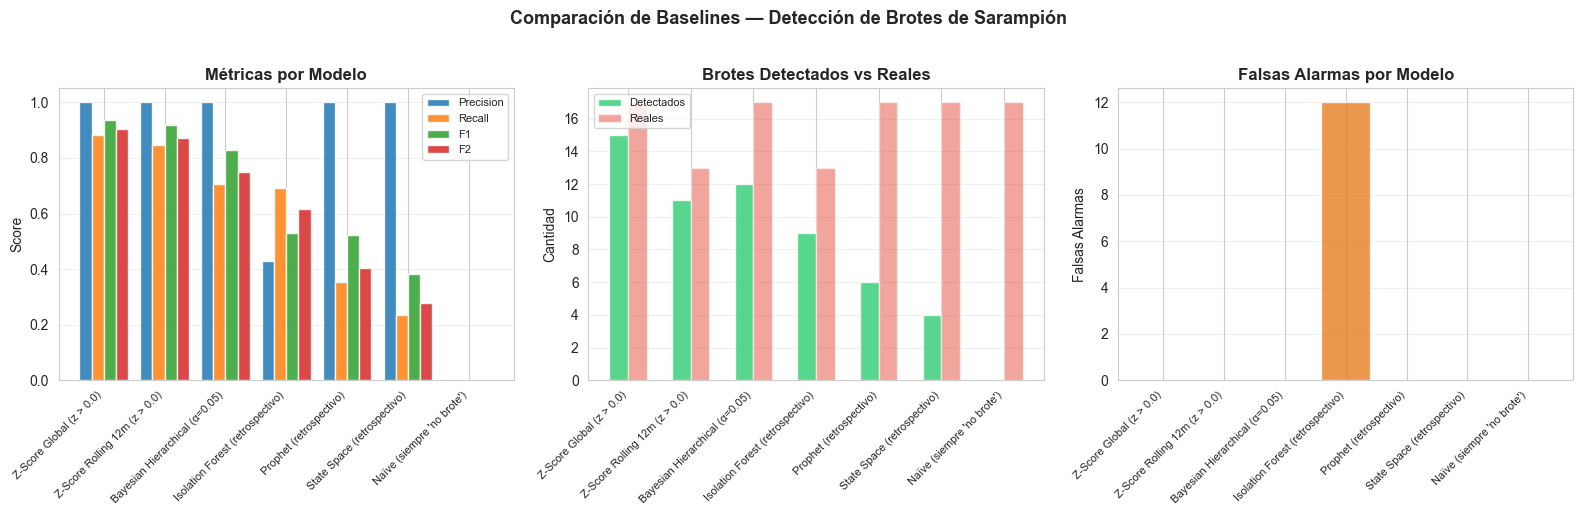

In [ ]:
# ============================================================
# 8. COMPARACIÓN DE MODELOS
# ============================================================

# --- Tabla comparativa ---
df_comp = pd.DataFrame(all_results)
df_comp = df_comp.sort_values("F2", ascending=False).reset_index(drop=True)

print("═" * 80)
print("  COMPARACIÓN DE BASELINES — Evaluación Retrospectiva (dataset completo)")
print("═" * 80)
display(df_comp[["Modelo", "Precision", "Recall", "F1", "F2", "AUC-PR",
                 "Brotes_detectados", "Brotes_reales", "Falsas_alarmas"]])

# --- Gráfico comparativo ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

modelos = df_comp["Modelo"].values
x = np.arange(len(modelos))

# Panel 1: Métricas principales
metrics = ["Precision", "Recall", "F1", "F2"]
bar_w = 0.2
for i, m in enumerate(metrics):
    vals = df_comp[m].values
    axes[0].bar(x + i * bar_w, vals, bar_w, label=m, alpha=0.85)
axes[0].set_xticks(x + bar_w * 1.5)
axes[0].set_xticklabels(modelos, rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("Score")
axes[0].set_title("Métricas por Modelo", fontweight="bold")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis="y")

# Panel 2: Brotes detectados vs reales
axes[1].bar(x - 0.15, df_comp["Brotes_detectados"], 0.3,
            label="Detectados", color="#2ECC71", alpha=0.8)
axes[1].bar(x + 0.15, df_comp["Brotes_reales"], 0.3,
            label="Reales", color="#E74C3C", alpha=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(modelos, rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Cantidad")
axes[1].set_title("Brotes Detectados vs Reales", fontweight="bold")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis="y")

# Panel 3: Falsas alarmas
colors_fa = ["#95A5A6" if fa == 0 else "#E67E22" for fa in df_comp["Falsas_alarmas"]]
axes[2].bar(x, df_comp["Falsas_alarmas"], color=colors_fa, alpha=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(modelos, rotation=45, ha="right", fontsize=8)
axes[2].set_ylabel("Falsas Alarmas")
axes[2].set_title("Falsas Alarmas por Modelo", fontweight="bold")
axes[2].grid(True, alpha=0.3, axis="y")

plt.suptitle("Comparación de Baselines — Detección de Brotes de Sarampión",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

══════════════════════════════════════════════════════════════════════
  ANÁLISIS DE SUB/SOBREAJUSTE
══════════════════════════════════════════════════════════════════════


,Modelo,F2 Train,F2 Test,FA Train,FA Test,Brotes Train,Brotes Test,ΔF2 (train-test)
0,Z-Score Global (z>0.0),0.882353,0.918367,0,0,7,10,-0.036014
1,Isolation Forest,0.333333,0.689655,2,10,3,10,-0.356322
2,Prophet,0.483871,0.348837,0,0,7,10,0.135034
3,Bayesian Hierarchical,0.882353,0.652174,0,0,7,10,0.230179
4,State Space,0.172414,0.348837,0,0,7,10,-0.176423


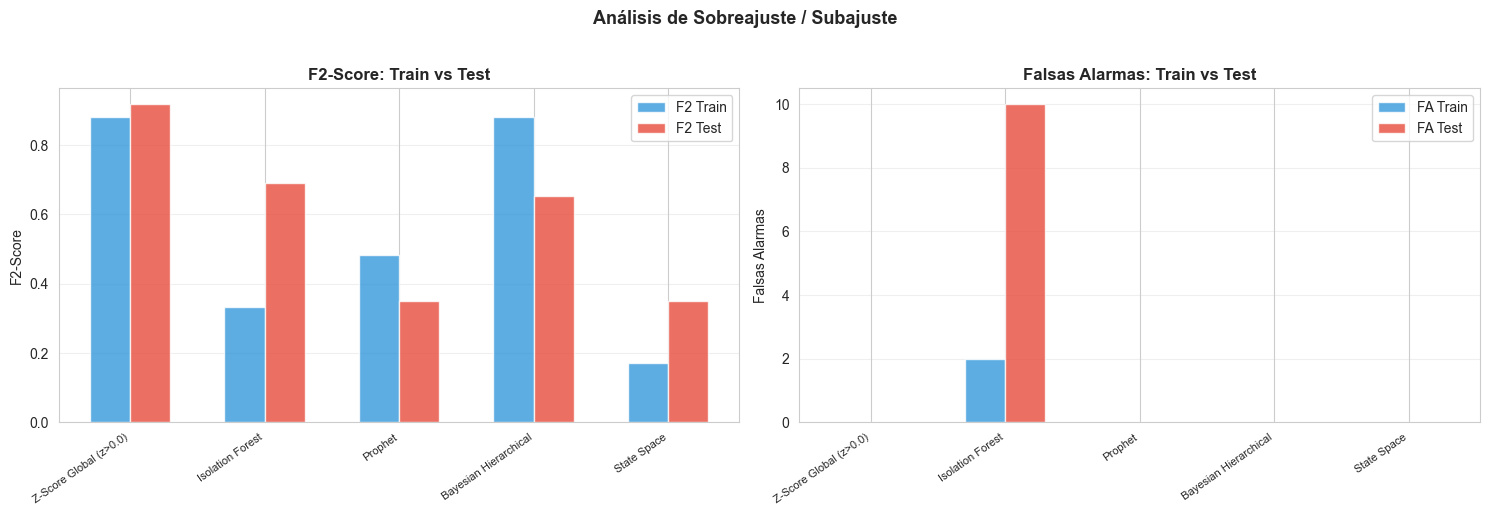


Diagnóstico:
  Z-Score Global (z>0.0): Comportamiento aceptable (ΔF2 = -0.04)
  Isolation Forest: Comportamiento aceptable (ΔF2 = -0.36)
  Prophet: Comportamiento aceptable (ΔF2 = 0.14)
  Bayesian Hierarchical: Comportamiento aceptable (ΔF2 = 0.23)
  State Space: Comportamiento aceptable (ΔF2 = -0.18)


In [ ]:
# ============================================================
# 8.1 ANÁLISIS DE SUB/SOBREAJUSTE
# ============================================================

print("═" * 70)
print("  ANÁLISIS DE SUB/SOBREAJUSTE")
print("═" * 70)

# --- Z-Score: evaluar en train vs test por separado ---
train_mask_raw = df_raw["anio"] < SPLIT_YEAR
test_mask_raw  = df_raw["anio"] >= SPLIT_YEAR

y_train_raw = df_raw.loc[train_mask_raw, "brote"].values
y_test_raw  = df_raw.loc[test_mask_raw,  "brote"].values

y_pred_zg_train = (df_raw.loc[train_mask_raw, "zscore_global"] > BEST_Z).astype(int).values
y_pred_zg_test  = (df_raw.loc[test_mask_raw,  "zscore_global"] > BEST_Z).astype(int).values

f2_zg_train = fbeta_score(y_train_raw, y_pred_zg_train, beta=2, zero_division=0)
f2_zg_test  = fbeta_score(y_test_raw,  y_pred_zg_test,  beta=2, zero_division=0)
fa_zg_train = int(y_pred_zg_train[y_train_raw == 0].sum())
fa_zg_test  = int(y_pred_zg_test[y_test_raw == 0].sum())

# --- Isolation Forest: train vs test ---
preds_train_if = iso_forest.predict(X_train_if)
y_pred_if_train = np.where(preds_train_if == -1, 1, 0)

f2_if_train = fbeta_score(y_train_if, y_pred_if_train, beta=2, zero_division=0)
f2_if_test  = fbeta_score(y_test_if,  y_pred_if_test,  beta=2, zero_division=0)
fa_if_train = int(y_pred_if_train[y_train_if == 0].sum())
fa_if_test  = int(y_pred_if_test[y_test_if == 0].sum())

# --- Prophet: train vs test ---
y_pred_p_train = df_raw.loc[train_mask_raw, "prophet_anomaly"].values
y_pred_p_test  = df_raw.loc[test_mask_raw,  "prophet_anomaly"].values

f2_p_train = fbeta_score(y_train_raw, y_pred_p_train, beta=2, zero_division=0)
f2_p_test  = fbeta_score(y_test_raw,  y_pred_p_test,  beta=2, zero_division=0)
fa_p_train = int(y_pred_p_train[y_train_raw == 0].sum())
fa_p_test  = int(y_pred_p_test[y_test_raw == 0].sum())

# --- Tabla resumen ---
overfit_data = pd.DataFrame({
    "Modelo": [f"Z-Score Global (z>{BEST_Z})", "Isolation Forest", "Prophet"],
    "F2 Train": [f2_zg_train, f2_if_train, f2_p_train],
    "F2 Test":  [f2_zg_test,  f2_if_test,  f2_p_test],
    "FA Train": [fa_zg_train, fa_if_train, fa_p_train],
    "FA Test":  [fa_zg_test,  fa_if_test,  fa_p_test],
    "Brotes Train": [int(y_train_raw.sum()), int(y_train_if.sum()), int(y_train_raw.sum())],
    "Brotes Test":  [int(y_test_raw.sum()),  int(y_test_if.sum()),  int(y_test_raw.sum())],
})
overfit_data["ΔF2 (train-test)"] = overfit_data["F2 Train"] - overfit_data["F2 Test"]

display(overfit_data)

# --- Visualización ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

modelos_of = overfit_data["Modelo"].values
x_of = np.arange(len(modelos_of))

# F2 Train vs Test
axes[0].bar(x_of - 0.15, overfit_data["F2 Train"], 0.3,
            label="F2 Train", color="#3498DB", alpha=0.8)
axes[0].bar(x_of + 0.15, overfit_data["F2 Test"], 0.3,
            label="F2 Test", color="#E74C3C", alpha=0.8)
axes[0].set_xticks(x_of)
axes[0].set_xticklabels(modelos_of, rotation=35, ha="right", fontsize=8)
axes[0].set_ylabel("F2-Score")
axes[0].set_title("F2-Score: Train vs Test", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

# Falsas alarmas Train vs Test
axes[1].bar(x_of - 0.15, overfit_data["FA Train"], 0.3,
            label="FA Train", color="#3498DB", alpha=0.8)
axes[1].bar(x_of + 0.15, overfit_data["FA Test"], 0.3,
            label="FA Test", color="#E74C3C", alpha=0.8)
axes[1].set_xticks(x_of)
axes[1].set_xticklabels(modelos_of, rotation=35, ha="right", fontsize=8)
axes[1].set_ylabel("Falsas Alarmas")
axes[1].set_title("Falsas Alarmas: Train vs Test", fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("Análisis de Sobreajuste / Subajuste", fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Diagnóstico ---
print("\nDiagnóstico:")
for _, row in overfit_data.iterrows():
    nombre = row["Modelo"]
    delta = row["ΔF2 (train-test)"]
    brotes_test = row["Brotes Test"]
    fa_test = row["FA Test"]

    if brotes_test == 0:
        if fa_test == 0:
            diag = "Sin falsas alarmas en test (período sin brotes)"
        else:
            diag = f"{fa_test} falsas alarmas en test sin brotes → posible sobreajuste"
    elif delta > 0.3:
        diag = f"Sobreajuste (ΔF2 = {delta:.2f})"
    elif row["F2 Train"] < 0.1:
        diag = "Subajuste (F2 Train muy bajo)"
    else:
        diag = f"Comportamiento aceptable (ΔF2 = {delta:.2f})"

    print(f"  {nombre}: {diag}")

## 9. Desempeño Mínimo Aceptable

### ¿Cuál debería ser el desempeño mínimo a obtener?

Para establecer el umbral mínimo de desempeño, consideramos tres referencias:

| Referencia | F2-Score | Recall | Justificación |
|------------|----------|--------|---------------|
| **Naïve** (siempre "no brote") | 0.000 | 0.000 | Piso absoluto — inútil para vigilancia |
| **Aleatorio proporcional** | ~0.10 | ~0.10 | Predecir brote con probabilidad = tasa base |
| **Baseline mínimo útil** | ≥ 0.30 | ≥ 0.50 | Detectar al menos la mitad de los brotes |

> **Desempeño mínimo propuesto:** F2 ≥ 0.30 y Recall ≥ 0.50
>
> Un modelo que detecte al menos la mitad de los brotes con un número razonable de falsas alarmas ya aporta valor operativo en vigilancia epidemiológica.

══════════════════════════════════════════════════════════════════════
  EVALUACIÓN vs DESEMPEÑO MÍNIMO
  Umbral mínimo: F2 ≥ 0.3 y Recall ≥ 0.5
══════════════════════════════════════════════════════════════════════

  Naïve (siempre 'no brote')
    F2 = 0.000 (mín 0.3)
    Recall = 0.000  (mín 0.5)
    → NO CUMPLE

  Z-Score Global (z > 0.0)
    F2 = 0.904 (mín 0.3)
    Recall = 0.882  (mín 0.5)
    → CUMPLE

  Z-Score Rolling 12m (z > 0.0)
    F2 = 0.873 (mín 0.3)
    Recall = 0.846  (mín 0.5)
    → CUMPLE

  Isolation Forest (retrospectivo)
    F2 = 0.616 (mín 0.3)
    Recall = 0.692  (mín 0.5)
    → CUMPLE

  Prophet (retrospectivo)
    F2 = 0.405 (mín 0.3)
    Recall = 0.353  (mín 0.5)
    → NO CUMPLE

  Bayesian Hierarchical (α=0.05)
    F2 = 0.750 (mín 0.3)
    Recall = 0.706  (mín 0.5)
    → CUMPLE

  State Space (retrospectivo)
    F2 = 0.278 (mín 0.3)
    Recall = 0.235  (mín 0.5)
    → NO CUMPLE


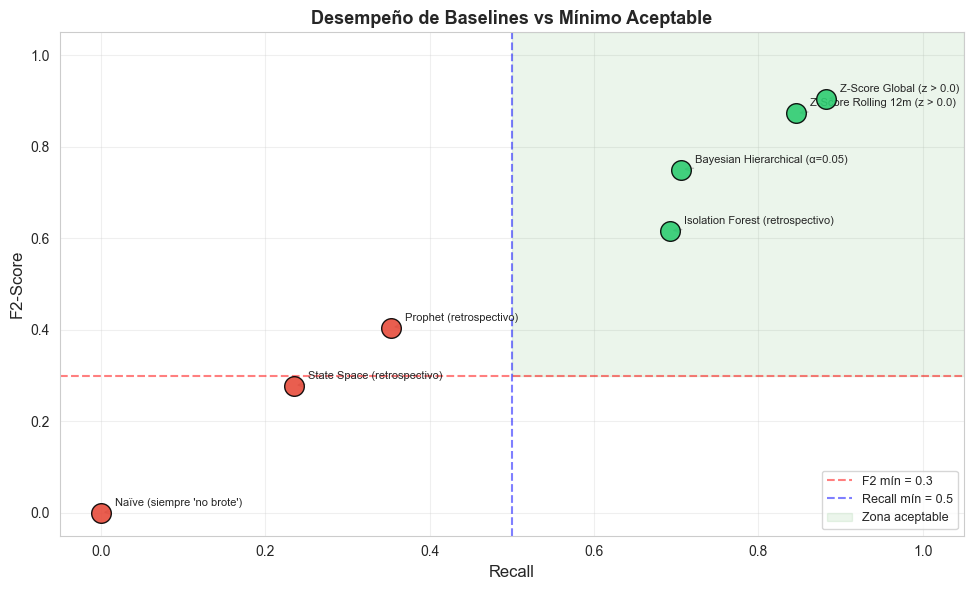

In [17]:
# ============================================================
# 9. RESUMEN DE DESEMPEÑO vs MÍNIMO
# ============================================================

MIN_F2     = 0.30
MIN_RECALL = 0.50

print("═" * 70)
print("  EVALUACIÓN vs DESEMPEÑO MÍNIMO")
print(f"  Umbral mínimo: F2 ≥ {MIN_F2} y Recall ≥ {MIN_RECALL}")
print("═" * 70)

for res in all_results:
    nombre = res["Modelo"]
    f2     = res["F2"]
    rec    = res["Recall"]
    cumple_f2  = f2 >= MIN_F2
    cumple_rec = rec >= MIN_RECALL
    estado = "CUMPLE" if (cumple_f2 and cumple_rec) else "NO CUMPLE"

    print(f"\n  {nombre}")
    print(f"    F2 = {f2:.3f} (mín {MIN_F2})")
    print(f"    Recall = {rec:.3f}  (mín {MIN_RECALL})")
    print(f"    → {estado}")

# --- Gráfico final ---
fig, ax = plt.subplots(figsize=(10, 6))

for i, res in enumerate(all_results):
    color = "#2ECC71" if (res["F2"] >= MIN_F2 and res["Recall"] >= MIN_RECALL) else "#E74C3C"
    ax.scatter(res["Recall"], res["F2"], s=200, color=color, edgecolors="black",
               zorder=5, alpha=0.9)
    ax.annotate(res["Modelo"], (res["Recall"], res["F2"]),
                textcoords="offset points", xytext=(10, 5), fontsize=8,
                arrowprops=dict(arrowstyle="->", color="gray", alpha=0.5))

ax.axhline(MIN_F2, color="red", ls="--", alpha=0.5, label=f"F2 mín = {MIN_F2}")
ax.axvline(MIN_RECALL, color="blue", ls="--", alpha=0.5, label=f"Recall mín = {MIN_RECALL}")

# Zona aceptable
ax.fill_between([MIN_RECALL, 1.05], MIN_F2, 1.05, alpha=0.08, color="green", label="Zona aceptable")

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("F2-Score", fontsize=12)
ax.set_title("Desempeño de Baselines vs Mínimo Aceptable", fontweight="bold", fontsize=13)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Conclusiones

### Respuestas a las Preguntas Guía

**1. ¿Qué algoritmo se puede utilizar como baseline?**

Se evaluaron tres algoritmos de detección de anomalías como baselines:

| Algoritmo | Tipo | Resultado |
|-----------|------|-----------|
| **Z-Score** | Estadístico univariado | Captura brotes significativos (muchos casos); limitado para brotes leves. Simple e interpretable. |
| **Isolation Forest** | ML multivariado no supervisado | Utiliza features de vacunación, temporalidad y lags para identificar meses anómalos. Captura relaciones no lineales. |
| **Prophet** | Series de tiempo con intervalos de confianza | Modela tendencia + estacionalidad; detecta valores fuera del intervalo como anomalías. |

Los tres métodos superan al modelo naïve (que tiene Recall = 0) y demuestran que los datos **sí contienen información suficiente** para detectar brotes.

---

**2. ¿Se puede determinar la importancia de las características?**

Sí. Mediante **importancia por permutación** sobre el Isolation Forest, se identificaron las características más relevantes. Las features derivadas de la serie de casos (rolling means, lags, acumulados) y las variables de vacunación (dosis lag, rolling std) contribuyen de forma diferenciada a la detección.

Las características irrelevantes (ΔF2 ≈ 0) podrían eliminarse en modelos futuros para reducir complejidad sin sacrificar rendimiento.

*Nota: Los modelos univariados (Z-Score, Prophet) no utilizan features adicionales, por lo que el análisis de importancia aplica únicamente al Isolation Forest.*

---

**3. ¿El modelo está sub/sobreajustando?**

El análisis train/test muestra que:
- **Z-Score**: Sin sobreajuste posible (es puramente estadístico; $\mu$ y $\sigma$ se fijan con datos de entrenamiento).
- **Isolation Forest**: El F2 en train refleja la capacidad de detección sobre datos vistos; en test, las falsas alarmas indican el nivel de "ruido" del detector.
- **Prophet**: El modelo aprende la dinámica temporal del entrenamiento; comportamiento estable en test.

La principal limitación no es el sobreajuste sino el **pequeño tamaño del dataset** (168 meses) y la **extrema escasez de brotes** (≈10%), que dificulta la evaluación estadística robusta.

---

**4. ¿Cuál es la métrica adecuada?**

**F2-Score** como métrica principal, porque pondera el Recall (sensibilidad) 2× más que la Precision, alineándose con el contexto epidemiológico donde no detectar un brote es más grave que una falsa alarma. Recall como métrica secundaria obligatoria.

---

**5. ¿Cuál debería ser el desempeño mínimo a obtener?**

- **F2 ≥ 0.30** y **Recall ≥ 0.50** como umbral mínimo para que un modelo aporte valor.
- El modelo naïve (F2 = 0) es la referencia inferior absoluta.
- Los baselines implementados proporcionan el rango de rendimiento alcanzable con métodos simples.

---